In [ ]:
# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

***Answer*** :

Using different regression techiques, find the one that best fits this data. Determine which features affect the price more than others.

Depending on the co-efficients, determine which features have higher importance on the car price.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1140]:
#!pip install feature_engine
#import basic modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#modules for feature engineering
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder, PolynomialFeatures, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

# modeling modules
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, ElasticNetCV

#model selection module
from sklearn.model_selection import GridSearchCV

# module for metrics
from sklearn.metrics import mean_squared_error


In [1141]:
#import the data
df = pd.read_csv("data/vehicles.csv")
df.head(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


In [1142]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

(426880, 18)

In [1143]:
#checking non null values counts
df.isnull().sum().sort_values(ascending=False)

#Finding : There are large amount of null values in the data

size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
id                   0
region               0
price                0
state                0
dtype: int64

In [1144]:
#percentage of null values in size column
df['size'].isna().mean()

#since % of null values in size column is 

np.float64(0.7176747563718141)

In [1145]:
#percentage of null values in cylinders column
df['cylinders'].isna().mean()

#since cylinders have 60% non null values, we will keep this column and handle the null values

np.float64(0.416224700149925)

In [1146]:
print("Descriptive statistics for categorical variables")
df.describe(include=['object', 'category'])

# FINDING - Among the catigorical columns there are some columns with very high cardinality.

Descriptive statistics for categorical variables


,region,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,state
count,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426880
unique,404,42,29649,6,8,5,6,3,118246,3,4,13,12,51
top,columbus,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,ca
freq,3608,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,50614


In [1147]:
print("Descriptive statistics for numerical variables")
df.describe()

# FINDING : there is a wide range in minimum and maximum values for price and odometer, indicating we will need to log transform

Descriptive statistics for numerical variables


,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [1148]:
#checking for unique values in columns
df.nunique().sort_values(ascending=False)

id              426880
VIN             118246
odometer        104870
model            29649
price            15655
region             404
year               114
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

In [1149]:
#looking at values in object and category columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

unique_values = {col: df[col].unique() for col in cat_cols}

#unique_values

#Finding : 
# Ordinal columns: size, condition - (encode using Ordinal transformer) 
# high cardinality columns (>40 unique values) : region, manufacture, model, state - (encode using Target encoder)
# Nominal columns : cylinders,fuel,title_status,transmission,drive,type,paint_color - (encode using One hot encoder)


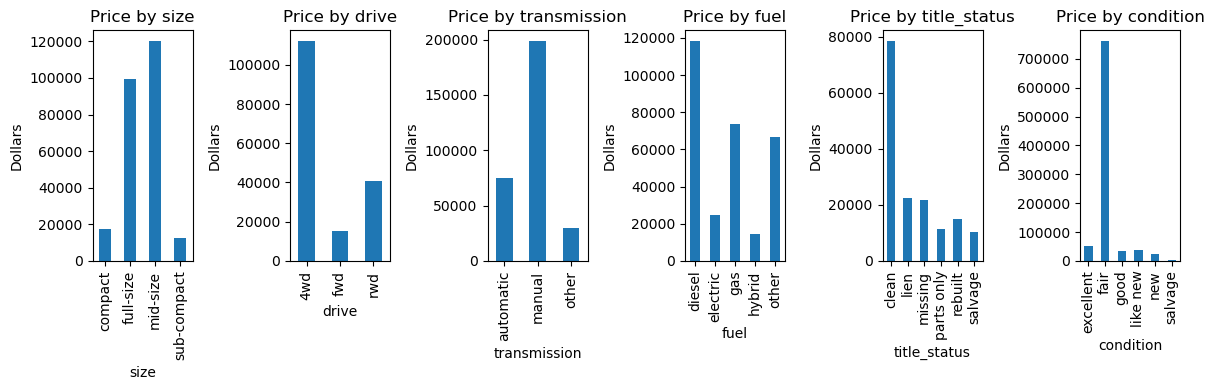

In [1150]:
# Let's explore the price by columns that seem categorical
categorical_columns = ['size', 'drive', 'transmission','fuel','title_status','condition']

fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for i, column in enumerate(categorical_columns):
    mean_costs = df.groupby(column)['price'].mean()
    mean_costs.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Price by {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Dollars')

plt.tight_layout()
plt.show()

# Finding : there is a clear spike in price for specific values in condition, title_status,fuel,transmission, drive and size
#This tells us that cars having those feature values are clearly drive up the price.

,avg_price,count
region,,
frederick,4.914334e+06,288
delaware,3.205056e+06,949
humboldt county,2.902730e+06,385
modesto,1.401324e+06,2973
knoxville,1.369993e+06,2763
eugene,1.266306e+06,2985
south jersey,1.030897e+06,2974
stillwater,6.477323e+05,198
birmingham,6.173156e+05,1647


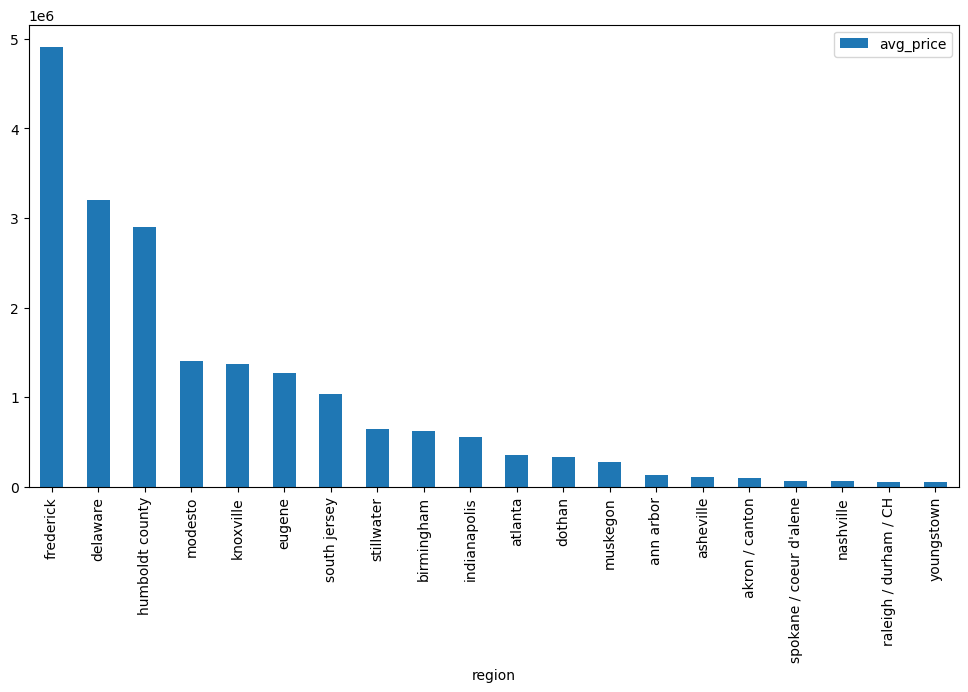

In [1151]:
region_stats = (
    df.groupby("region")
      .agg(avg_price=("price","mean"),
           count=("price","size"))
)

region_stats = region_stats[region_stats["count"] > 30]  # filtering low volume

region_stats.sort_values("avg_price", ascending=False)\
            .head(20)\
            .plot(kind="bar", y="avg_price", figsize=(12,6))
region_stats.sort_values("avg_price", ascending=False).head(20)

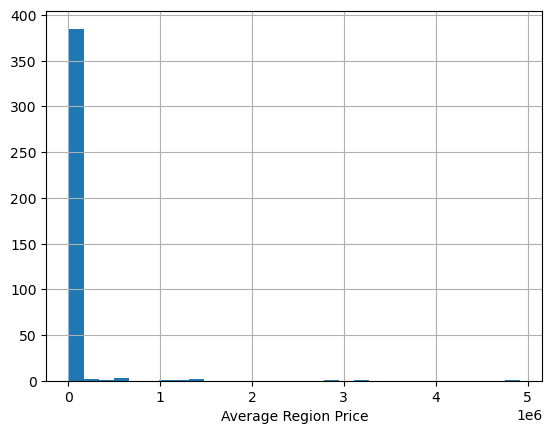

In [1152]:
region_stats["avg_price"].hist(bins=30)
plt.xlabel("Average Region Price")
plt.show()


,avg_price,count
model,,
benz e320,3.878579e+07,78
f350 super duty lariat,9.149379e+06,122
4runner,3.500367e+06,1073
tundra,2.643434e+06,1425
sierra 2500,1.145794e+06,109
regal,7.473896e+05,167
wrangler,5.141020e+05,2848
ranger,1.321955e+05,813
Lamborghini Huracan,8.847512e+04,42


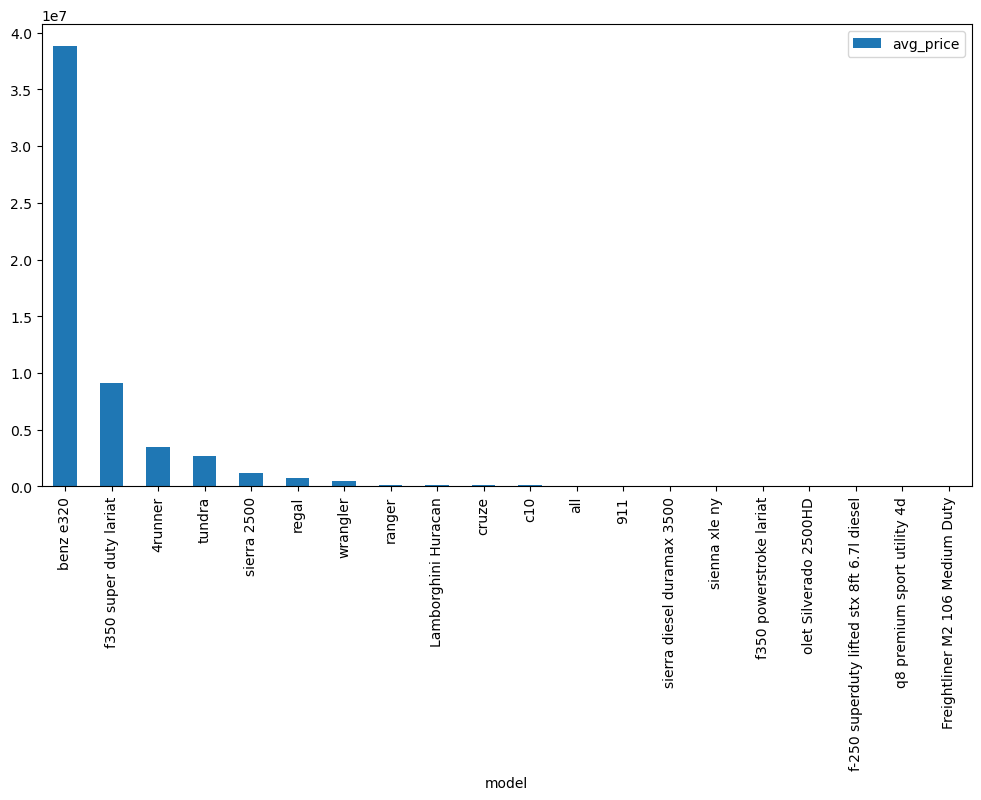

In [1153]:
model_stats = (
    df.groupby("model")
      .agg(avg_price=("price","mean"),
           count=("price","size"))
)

model_stats = model_stats[model_stats["count"] > 30]  # filtering low volume

model_stats.sort_values("avg_price", ascending=False)\
            .head(20)\
            .plot(kind="bar", y="avg_price", figsize=(12,6))
model_stats.sort_values("avg_price", ascending=False).head(20)

#from model data it seems like there is some garbage data like '911', 'all' etc , we will be dropping this column.
#manufacturer gives us a better idea of make of the car than model.

,avg_price,count
manufacturer,,
ford,36411.718025,70985
chevrolet,115676.101645,55064
toyota,234294.682621,34202
honda,10751.363722,21269
nissan,18827.332826,19067
jeep,150717.819659,19014
ram,27728.339167,18342
gmc,30405.877152,16785
bmw,26740.261446,14699


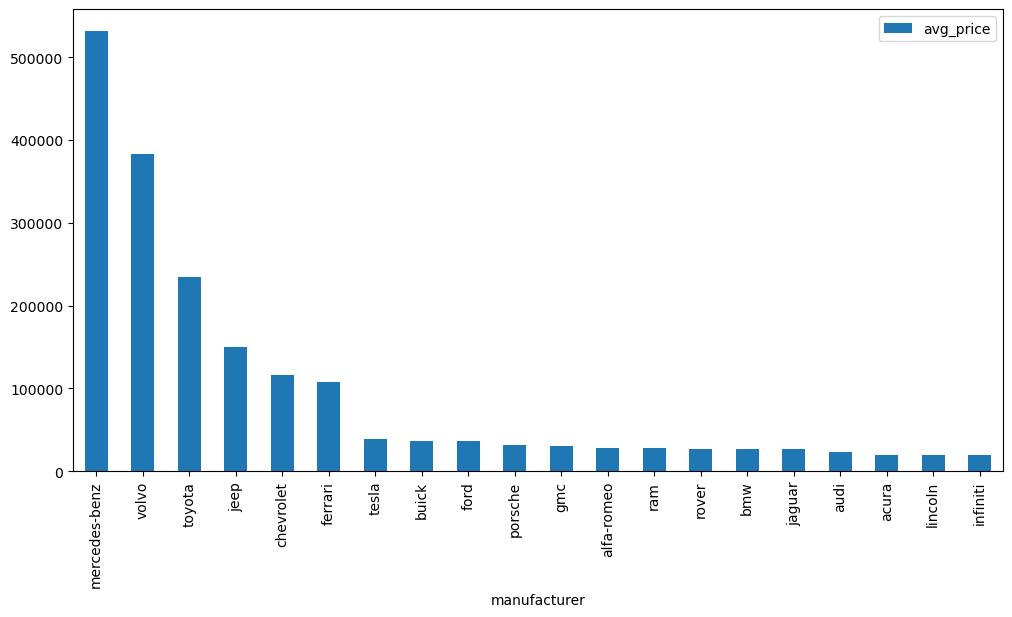

In [1154]:
manufacturer_stats = (
    df.groupby("manufacturer")
      .agg(avg_price=("price","mean"),
           count=("price","size"))
)

manufacturer_stats = manufacturer_stats[manufacturer_stats["count"] > 30]  # filtering low volume

manufacturer_stats.sort_values("avg_price", ascending=False)\
            .head(20)\
            .plot(kind="bar", y="avg_price", figsize=(12,6))

manufacturer_stats.sort_values("count", ascending=False).head(20)

#Finding for high cardinal columns, region, manufacturer,state, we will have to do 

,avg_price,count
state,,
me,13782.824343,2966
va,13877.008759,10732
dc,14480.132323,2970
ct,15039.162876,5188
pa,15542.140915,13753
ma,15582.394421,8174
mn,16037.204769,7716
ia,16183.885774,8632
ri,16424.106466,2320


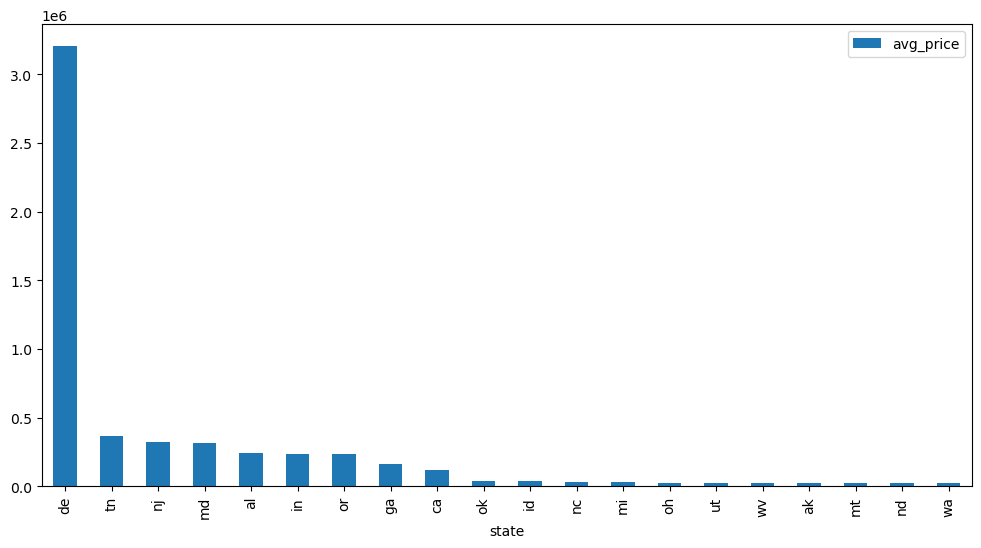

In [1155]:
state_stats = (
    df.groupby("state")
      .agg(avg_price=("price","mean"),
           count=("price","size"))
)

state_stats = state_stats[state_stats["count"] > 30]  # filtering low volume

state_stats.sort_values("avg_price", ascending=False)\
            .head(20)\
            .plot(kind="bar", y="avg_price", figsize=(12,6))

state_stats.sort_values("avg_price", ascending=True).head(20)

#Finding for high cardinal columns, region, manufacturer,state, we will have to do 

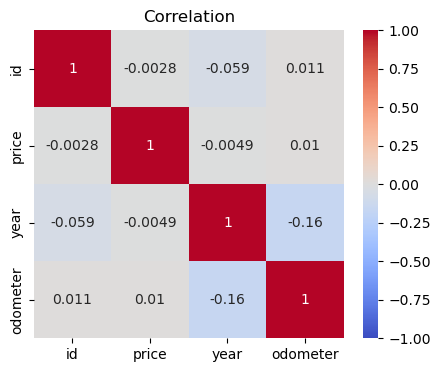

In [1156]:
#relationship between numerical values
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Create a correlation heatmap using just the numerical features
plt.figure(figsize=(5, 4))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation')
plt.show()

In [1157]:
#Calculating p-value of different columns to see their effects on price

import scipy.stats as stats

cols = ['region','manufacturer','year','cylinders','type','state','fuel','title_status','transmission','drive','paint_color','condition','odometer']

for i in cols:
    groups = [group['price'].values for name, group in df.groupby(i)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f" {i} : {p_value}") 

 region : 0.9999999962556322
 manufacturer : 0.8975582566734809
 year : 4.190785853319762e-32
 cylinders : 0.7547482085592394
 type : 0.5157619289300106
 state : 0.0008838583902242701
 fuel : 0.9689073949660602
 title_status : 0.9965662629256854
 transmission : 0.1816224237635435
 drive : 0.11128211912990851
 paint_color : 0.08047659136524714
 condition : 3.234213952285431e-05
 odometer : 0.9999999999999999


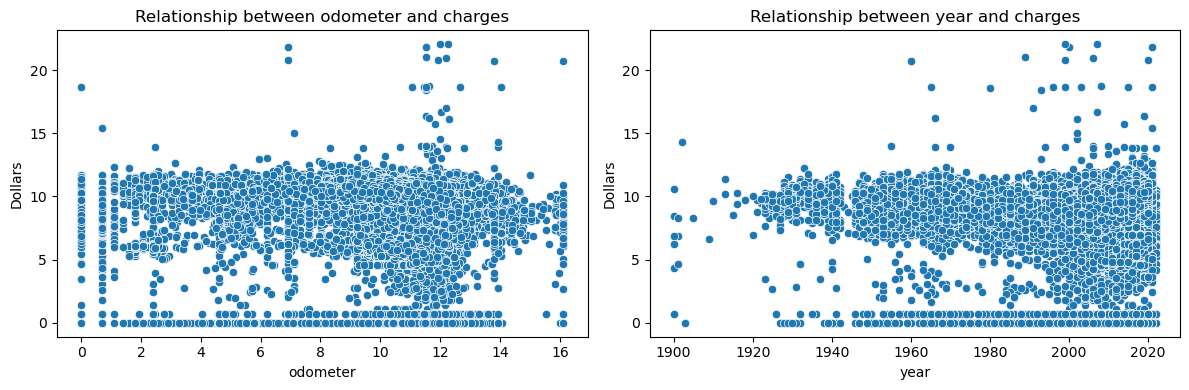

In [1158]:
num_col = ['odometer','year']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#df['odometer'] = np.log1p(df['odometer'])
#df['price'] = np.log1p(df['price'])
df_scaled = df[['odometer', 'price','year']].copy()
df_scaled['odometer'] = np.log1p(df_scaled['odometer'])
df_scaled['price'] = np.log1p(df_scaled['price'])

for i, column in enumerate(num_col):
    sns.scatterplot(x=df_scaled[column], y=df_scaled['price'], ax=axes[i])
    axes[i].set_title(f'Relationship between {column} and charges')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Dollars')
    
plt.tight_layout()
plt.show()



### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [1159]:
#lets drop the columns that are not required in our modelling

df = df.drop(columns = ["id","manufacturer","VIN","model","size",'odometer','transmission','region','title_status','fuel','cylinders'],axis=1)

In [1160]:
df.head()
df.shape

(426880, 7)

In [1161]:
#Price has a wide range causing skewing in error and score calculations, so removing the ouliers
lower = df["price"].quantile(0.1)
upper = df["price"].quantile(0.99)

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

df.shape

(380521, 7)

In [1162]:
df['price'].describe()

count    380521.000000
mean      18612.002021
std       13300.343688
min         500.000000
25%        7600.000000
50%       15590.000000
75%       27500.000000
max       66995.000000
Name: price, dtype: float64

In [1163]:
#before tranforming any columns we will divide our data into training and test to maintain integrity
# Define target and features
X = df.drop(columns='price')
y = df['price']


In [1164]:
# It was found that by splitting the entire dataset 70:30 ratio,the model fitting time was too long causing the notebook to hang
# To prevent this smaller sample is taken to get the best values for hyperparameters

y_binned = pd.qcut(y, q=10, labels=False)

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=150000,
    stratify=y_binned,
    random_state=42
)

In [1165]:
print(f"X_Sample : {X_sample.shape}")
print(f"y_sample : {y_sample.shape}")

X_Sample : (150000, 6)
y_sample : (150000,)


In [1166]:
# Create list for categorical and numeric columns
tar_cols = ['state']
one_hot_cols = ['type','paint_color','drive']
num_cols = ['year']
#freq_cols = ['type','paint_color','condition','transmission','drive','cylinders']
cond_cols = ['condition']

#conditional column order
condition_order = [
    'salvage',
    'fair',
    'good',
    'excellent',
    'like new',
    'new'
]

# from feature_engine.encoding import CountFrequencyEncoder
# from feature_engine.imputation import CategoricalImputer
from category_encoders import TargetEncoder

#Transformers for categorical and numerical columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
   # ('log', FunctionTransformer(lambda X: np.log1p(X), validate=False)),
    ('scaler', StandardScaler(with_mean=False))
])

# freq_transformer = Pipeline([
#     ('imputer', CategoricalImputer(
#         imputation_method='missing',
#         variables=freq_cols
#     )),
#     ('encoder', CountFrequencyEncoder(
#         encoding_method='frequency',
#         variables=freq_cols
#     ))
# ])

onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(drop='first',handle_unknown='ignore'))
])

condition_encoder = OrdinalEncoder(
    categories=[condition_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

condition_transformer = Pipeline([
    ('ordinal', condition_encoder),
    ('scaler', StandardScaler(with_mean=False))
])

tar_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', TargetEncoder(cols=tar_cols, smoothing=0.2))
])

#define the column transformer using the pipelines above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('one_hot', onehot_transformer, one_hot_cols),
       # ('freq', freq_transformer,freq_cols),
        ('con', condition_transformer,cond_cols),
        ('tar', TargetEncoder(cols=tar_cols), tar_cols)
    ],
    n_jobs=-1,
    verbose=True)


## NOTE : the TargetEncoder from SciKit learn was returning multiple columns like one-hot encoder 
#Causing the application from going out of memory and freezing jupiter.

In [1167]:
# Defining some methods to use with different models

def fit_model(name:str, regressor):
    '''
    Method to create a pipeline and fit a model
    '''    
    model = TransformedTargetRegressor(
    regressor = regressor,
    func=np.log1p,
    inverse_func=np.expm1
    )
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        (name, model)
    ])

    pipeline.fit(X_train, y_train)
    return pipeline

In [1168]:
def get_rmse(pipe: Pipeline):
    '''
    Method to get model's RMSE
    '''
    train_pred = pipe.predict(X_train)
    train_mse = mean_squared_error(y_train, train_pred)

    test_pred = pipe.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    test_rmse = round(np.sqrt(test_mse), 4)
    train_rmse= round(np.sqrt(train_mse), 4)

    return [train_rmse, test_rmse]

In [1169]:
def get_rscore(model):
    '''
    Method to get r score
    '''
    r_sq = model.score(X_train, y_train)
    
    return r_sq

In [1186]:
#dataframe for different model statistics
stats_df = pd.DataFrame(columns=['Model Name', 'Alpha', 'l1-ratio', 'Train RMSE','Test RMSE',
                          'R-Squared'])

def update_results_df(algorithm_name, model, alpha = '-', l1_ratio = '-'):
    '''
    Method to update different model statistics
    '''
    global stats_df
    key_cols = ["Model Name"]
    
    new_row = {
        'Model Name': algorithm_name,
        'Alpha': alpha, 
        'l1-ratio': l1_ratio, 
        'Train RMSE': get_mse(model)[0],
        'Test RMSE': get_mse(model)[1], 
        'R-Squared': get_rscore(model)
    }
   
    stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True).drop_duplicates(subset=key_cols, keep="last")


In [1171]:
def fit_sample_model(name:str, regressor):
    '''
    Method to create a pipeline and fit a sample model
    '''
    model_sample = TransformedTargetRegressor(
    regressor = regressor,
    func=np.log1p,
    inverse_func=np.expm1
    )
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        (name, model_sample)
    ])

    pipeline.fit(X_sample, y_sample)
    return pipeline

In [1172]:
def get_best_params(name, pipe:Pipeline):
    '''
    Gets the best value for hyper parameters from sample data
    '''
    best_alpha = pipe.named_steps[name].regressor_.alpha_
    best_l1 = pipe.named_steps[name].regressor_.l1_ratio_
    return {'alpha' : best_alpha, 'l1-ratio' : best_l1}

In [1173]:
def get_coeff(name,pipeline):
    '''
    Gets the top 10 co-efficients from different models.
    '''
    coefs = pipeline.named_steps[name].regressor_.coef_

    coef_df = pd.DataFrame({
        'Feature': col_names,
        'Coefficient': coefs
    }).set_index('Feature')
    coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10))

In [1174]:
def get_coeff_plot(name,pipeline):
    '''
    Plotting the co-efficients
    '''
    coefs = pipeline.named_steps[name].regressor_.coef_
    coef_df = pd.DataFrame({
        'feature': col_names,
        'coefficient': coefs
    })

    coef_df["abs_coef"] = np.abs(coef_df["coefficient"])
    coef_df = coef_df.sort_values("abs_coef")
    
    # Plot
    plt.figure(figsize=(15,10))
    plt.barh(coef_df["feature"], coef_df["coefficient"])
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.title("Model Coefficients (Top Features)")
    plt.gca().invert_yaxis()
    plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [1128]:
# Running regression on sample data to get the best values for hyperparameters 
name = 'elastic_sample'
elastic_sample = ElasticNetCV(
    l1_ratio=[0.01,0.1, 0.2, 0.5],
    alphas=[0.001, 0.01, 0.1, 1,5,10,15,20,30],
    cv=5,
    n_jobs=-1
)
pipe = fit_sample_model(name, elastic_sample)

In [1129]:
print(get_best_params(name,pipe))

{'alpha': np.float64(0.001), 'l1-ratio': np.float64(0.01)}


In [1175]:
# Split the whole data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

In [1176]:
#Fitting elastic net model with the best params
elastic = ElasticNet(alpha=0.001, l1_ratio=0.01)

elastic_model = 'elastic'
elastic_pipe = fit_model(elastic_model, elastic)


In [1177]:
#getting coefficients
one_hot_columns = preprocessor.named_transformers_['one_hot'].get_feature_names_out(one_hot_cols)
col_names = list(tar_cols) + list(one_hot_columns) + list(num_cols) + list(cond_cols)

get_coeff(elastic_model,elastic_pipe)

                    Coefficient
Feature                        
type_other             0.528507
type_pickup            0.523814
type_convertible       0.413329
drive_fwd             -0.409993
type_coupe             0.374120
type_truck             0.355963
state                  0.355455
type_offroad           0.199229
paint_color_orange     0.178307
paint_color_yellow     0.174711


In [1133]:
#Below debugging steps were carried out as error and r-score was in high ranges. This was found to happen due to outliers in price data.
#To get more accurate result, quartile range of price was considered from 0.1% > price < 90%

#DEBUG step - Checking predictions 
preds = elastic_pipe.predict(X_test)

print(f"preds :{preds[:5]}")
print(f"y_test[:5] : {y_test[:5]}")

preds :[ 9867.29412141  5702.8515018   9366.53898693 11979.38076663
 36640.39470903]
y_test[:5] : 266826    18990
34639      2500
23124     16590
276469    11500
412060    29999
Name: price, dtype: int64


In [1134]:
#DEBUG step - Checking tranformed columns number 
X_transformed = elastic_pipe.named_steps["preprocess"].transform(X_train)
print("Feature shape:", X_transformed.shape)


Feature shape: (304416, 31)


In [1135]:
#DEBUG step - checking price ranges
print(y_train.describe())


count    304416.000000
mean      18608.885407
std       13299.414156
min         500.000000
25%        7595.750000
50%       15590.000000
75%       27500.000000
max       66995.000000
Name: price, dtype: float64


In [1187]:
update_results_df("Elastic Net", elastic_pipe, 0.001, 0.01)
stats_df

/var/folders/c2/kgzx1gtn69zbvq_n_sj08vkm0000gn/T/ipykernel_60071/3918499922.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, pd.DataFrame([new_row])], ignore_index=True).drop_duplicates(subset=key_cols, keep="last")


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.001,0.01,10872.4797,10949.6915,0.331666


In [1188]:
#Getting best alpha value and l1=1 for LASSO regression
alpha_param = [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40, 60]
name = 'lasso_sample'
lasso_sample = ElasticNetCV(
    l1_ratio=1,
    alphas=alpha_param,
    cv=5,
    n_jobs=-1
)
pipe = fit_sample_model(name, lasso_sample)

print(get_best_params(name,pipe))

{'alpha': np.float64(0.0001), 'l1-ratio': np.int64(1)}


In [1189]:
#Fitting elastic net model with the best params
elastic_lasso = ElasticNet(alpha=0.0001, l1_ratio=1)

lasso_model = 'lasso'
lasso_pipe = fit_model(lasso_model, elastic_lasso)

In [1190]:
get_coeff(lasso_model,lasso_pipe)
update_results_df("Lasso Regression", lasso_pipe, 0.0001, 1)
stats_df

                    Coefficient
Feature                        
type_other             0.547594
type_pickup            0.538509
type_convertible       0.443301
drive_fwd             -0.411560
type_coupe             0.392725
type_truck             0.370806
state                  0.355311
type_offroad           0.279615
paint_color_orange     0.192946
paint_color_yellow     0.184834


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
1,Lasso Regression,0.0001,1.00,10866.8594,10944.5803,0.332357


In [1191]:
# SGDRegressor
sgd_regressor = SGDRegressor(
    penalty="elasticnet",     
    alpha=0.001,              
    l1_ratio=0.15,              
    max_iter=5000,
    random_state=42
)

sgd_model = 'sgd_model'
sgd_pipe = fit_model(sgd_model, sgd_regressor)


In [1192]:
get_coeff(sgd_model,sgd_pipe)
update_results_df("SGDRegressor", sgd_pipe, 0.001, 0.15)
stats_df

                     Coefficient
Feature                         
condition          -1.175330e+12
year                3.414969e+11
state              -2.348832e+11
paint_color_black  -1.463221e+11
type_pickup        -1.113555e+11
type_sedan          1.108536e+11
paint_color_silver  8.748454e+10
type_truck         -7.945899e+10
type_SUV            7.819256e+10
drive_Missing       7.804014e+10


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
1,Lasso Regression,0.0001,1.00,10866.8594,10944.5803,0.332357
2,SGDRegressor,0.0010,0.15,22873.6020,22888.9912,-1.958050


In [1193]:
# Tuned RIDGE
elastic_ridge = ElasticNet(
    l1_ratio=0,
    alpha = 0.0001
)

ridge_model = 'ridge'
ridge_pipe = fit_model(ridge_model, elastic_ridge)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 82844.90384350803, tolerance: 24.067556343185608
  model = cd_fast.sparse_enet_coordinate_descent(


In [1194]:
get_coeff(ridge_model,ridge_pipe)
update_results_df("Ridge Regression", ridge_pipe, 0.0001, 0)
stats_df


                    Coefficient
Feature                        
type_other             0.551688
type_pickup            0.542538
type_convertible       0.449275
drive_fwd             -0.411931
type_coupe             0.396924
type_truck             0.375370
state                  0.355250
type_offroad           0.326747
paint_color_orange     0.209245
paint_color_yellow     0.202649


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
1,Lasso Regression,0.0001,1.00,10866.8594,10944.5803,0.332357
2,SGDRegressor,0.0010,0.15,22873.6020,22888.9912,-1.958050
3,Ridge Regression,0.0001,0.00,10867.0061,10944.5516,0.332339


In [1195]:
#Fitting elastic net model with the best params
elastic_lasso_alpha = ElasticNet(alpha=0.05, l1_ratio=1)

lasso_model_alpha = 'lasso_alpha'
lasso_pipe_alpha = fit_model(lasso_model_alpha, elastic_lasso_alpha)

In [1196]:
get_coeff(lasso_model_alpha,lasso_pipe_alpha)
update_results_df("Lasso (Large alpha)", lasso_pipe_alpha, 0.05, 1)
stats_df

                    Coefficient
Feature                        
state                  0.309267
drive_fwd             -0.211842
condition              0.000050
type_convertible       0.000000
type_coupe             0.000000
year                   0.000000
drive_rwd              0.000000
type_bus              -0.000000
drive_Missing         -0.000000
paint_color_yellow     0.000000


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
1,Lasso Regression,0.0001,1.00,10866.8594,10944.5803,0.332357
2,SGDRegressor,0.0010,0.15,22873.6020,22888.9912,-1.958050
3,Ridge Regression,0.0001,0.00,10867.0061,10944.5516,0.332339
4,Lasso (Large alpha),0.0500,1.00,12318.2454,12357.0063,0.142105


In [1197]:
# Running regression on sample data to get the best values for hyperparameters from Grid Search
tuned_paramaters = [{'alpha':[1e-15, 1e-10, 1e-8, 1e-4,1e-3, 1e-2, 0.1, 1, 5, 10, 20, 40, 60, 80, 100]}]

grid_model = GridSearchCV(estimator = Ridge(), 
                          param_grid = tuned_paramaters, 
                          cv = 10)
name = 'grid_sample'

pipe = fit_sample_model(name, grid_model)


In [1198]:
#print(get_best_params(name,pipe))
pipe.named_steps["grid_sample"].regressor_.best_params_

{'alpha': 10}

In [1199]:
#Rige regression with optimal alpha=10 from Grid search
ridge_grid = Ridge(alpha = 1, max_iter = 5000)
ridge_grid_model = 'ridge_grid'
ridge_grid_pipe = fit_model(ridge_grid_model, ridge_grid)


In [1200]:
get_coeff(ridge_grid_model,ridge_grid_pipe)
update_results_df("Ridge (Grid Search CV)", ridge_grid_pipe, 10)
stats_df

                   Coefficient
Feature                       
drive_fwd            -0.393424
type_pickup           0.383470
state                 0.368831
type_other            0.236476
drive_Missing        -0.212517
type_truck            0.185116
paint_color_black     0.184719
drive_rwd             0.181967
paint_color_white     0.167849
type_sedan           -0.144076


,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
1,Lasso Regression,0.0001,1.0,10866.8594,10944.5803,0.332357
2,SGDRegressor,0.0010,0.15,22873.6020,22888.9912,-1.958050
3,Ridge Regression,0.0001,0.0,10867.0061,10944.5516,0.332339
4,Lasso (Large alpha),0.0500,1.0,12318.2454,12357.0063,0.142105
5,Ridge (Grid Search CV),10.0000,-,10985.8753,11062.5881,0.317652


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [1202]:
stats_df_sorted = stats_df.sort_values(by="Test RMSE")
stats_df_sorted

# FINDING - As seen below Ridge regression has the least test RMSE, this is the best fit for our data.
# Test RMSE for Ridge model is 10944.5, tells us that our model on average is off by $10,000 in price predictions.
# R-squared of this model is still low at 33% - we can explore other regression techniques to bring up this number.

,Model Name,Alpha,l1-ratio,Train RMSE,Test RMSE,R-Squared
3,Ridge Regression,0.0001,0.0,10867.0061,10944.5516,0.332339
1,Lasso Regression,0.0001,1.0,10866.8594,10944.5803,0.332357
0,Elastic Net,0.0010,0.01,10872.4797,10949.6915,0.331666
5,Ridge (Grid Search CV),10.0000,-,10985.8753,11062.5881,0.317652
4,Lasso (Large alpha),0.0500,1.0,12318.2454,12357.0063,0.142105
2,SGDRegressor,0.0010,0.15,22873.6020,22888.9912,-1.958050


In [1203]:
#Applying permutation importance to see which features are important from the ridge model
results = permutation_importance(ridge_pipe, X_test, y_test)
importances = pd.DataFrame(data=results.importances_mean, index=X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
print(importances)

#FINDING: Price is most dependent on age of the car, the type and drive of the car. 
# State, paint_color and car condition also drive the price up.

             Importance
year           0.298517
type           0.149175
drive          0.088941
state          0.026114
paint_color    0.019065
condition      0.004074


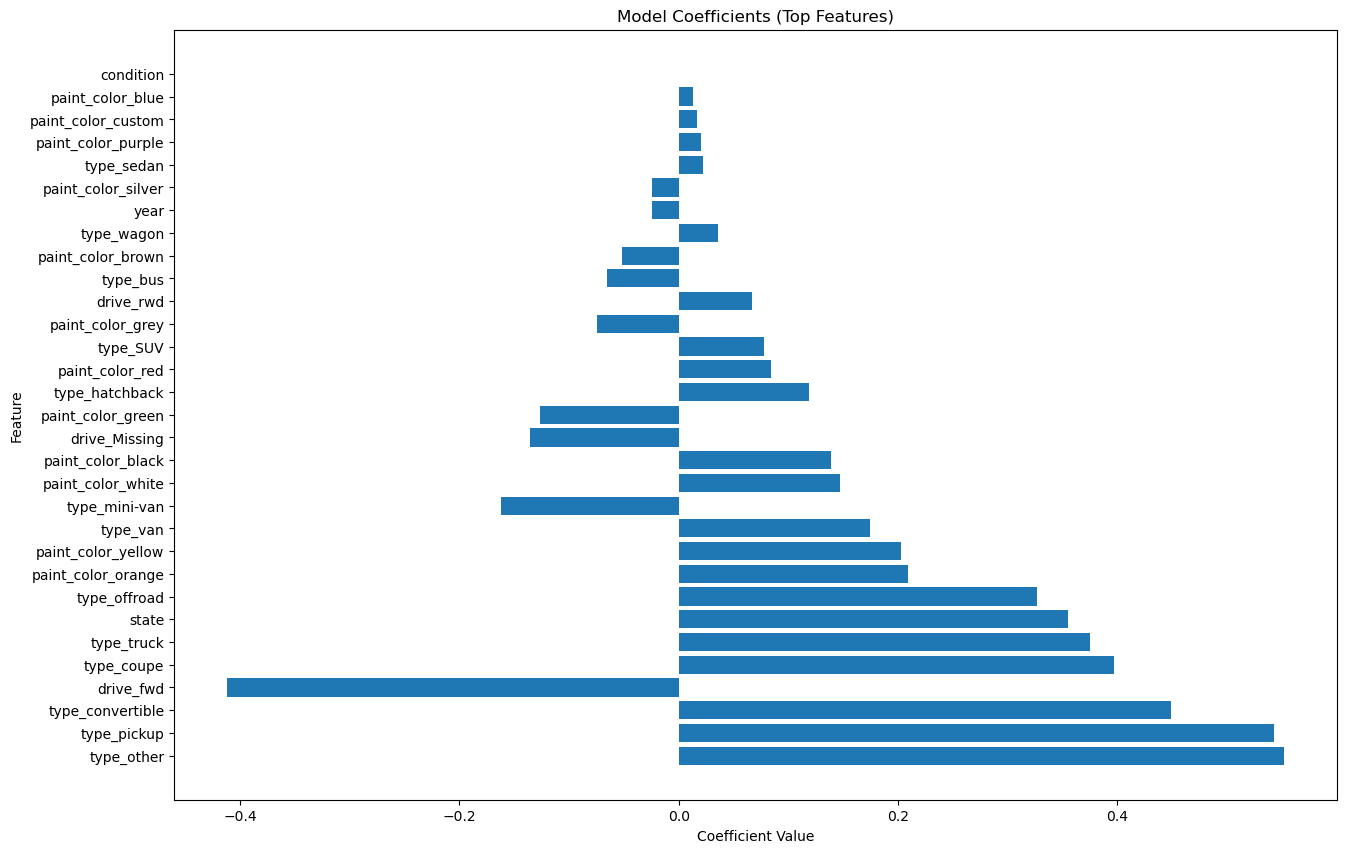

In [1204]:
#Plotting co-efficients for Ridge model
get_coeff_plot('ridge',ridge_pipe)

***FINDING : From the co-efficient chart***
1. Types, other, pickup and convertible have the highest positive effect on price.
2. Price drops significantly for car with forward drive 
3. Other types that also bring the price up are coupe,truck,offroad
4. Yellow and Orange being unique colors also drive the price up
5. State also has a moderate effect on price

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

***Primary Findings***

1. Customers are willing to pay higher price for certain types of cars.Types like pickup truck,convertible, coupe, truck, off-road cars and other types like sports cars can be priced higher in the inventory. Having cars like SUVs and Hatchbacks so bring in moderate revenue. Having mini-vans, wagon and sedan in inventory could hurt revenue as these are being sold at loss.

2. Front wheel drive significantly drops the price of a car. This could be cause of instability of these cars in icy or rainy conditions It would be better to have more rwd and awd in the inventory.Also customers prefer to know the specific drive type of the car when buying, missing this information can negatively affect the price.

3. Cars with orange and yellow colors being unique, can be priced higher.This could true in the sports car category.
   Other colors that customers prefer are white,black,silver and red. Green, gray and brown are not favored by customers, so these   should be rmoved from the inventory.

4. State also has an effect on the price, likely cars from certain states can be priced higher than others. States like West Virgina, Montana, Washinton show a higher value than states like Connecticut, Michigan and New Jersey.

5. Cars in better condition and that are newer are also preferred by customers, although these have a lower effect.